In [1]:
from tqec.computation.prism import BasisPrism, Position3DHex, ZXPrism
from tqec.computation.pipe_prism import PrismPipeKind
from tqec.computation.prism_graph import PrismGraph
from tqec.computation.correlation import find_correlation_surfaces

import mqt.qecc

import temp_utils

import numpy as np

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import mqt.qecc
import numpy as np
from matplotlib.patches import Polygon
import matplotlib.colors as mcolors

In [2]:
def plot_position_dict(
    *,
    size,
    color_assignment: dict[tuple, str],
    stabilizer_product: list[list[Position3DHex]] | None = None,
    star_operators = None
) -> plt.Figure:
    """Plot Position3DHex positions using their to_euclidean coords."""
    fig, ax = plt.subplots(figsize=size)
    for positions, color in color_assignment.items():
        if not positions:
            continue
        pts = np.array([p.to_euclidean()[:2] for p in positions])
        centroid = pts.mean(axis=0)
        angles = np.arctan2(pts[:, 1] - centroid[1], pts[:, 0] - centroid[0])
        pts = pts[np.argsort(angles)]
        rgba = mcolors.to_rgba(color, alpha=0.5)
        poly = Polygon(pts, closed=True,
                       facecolor=rgba, edgecolor=color, linewidth=1.5, zorder=2)
        ax.add_patch(poly)

    if stabilizer_product is not None:
        for stab in stabilizer_product:
            if not stab:
                continue
            if len(stab) != 2:
                pts = np.array([p.to_euclidean()[:2] for p in stab])
                centroid = pts.mean(axis=0)
                angles = np.arctan2(pts[:, 1] - centroid[1], pts[:, 0] - centroid[0])
                pts = pts[np.argsort(angles)]
                poly = Polygon(pts, closed=True,
                            facecolor=(0, 0, 0, 0.3), edgecolor="black", linewidth=2.0, zorder=4)
                ax.add_patch(poly)
                ax.plot(
                    [centroid[0] - 0.3, centroid[0] + 0.3],
                    [centroid[1], centroid[1]],
                    color="black", linewidth=1.5, zorder=5
                )
                ax.plot(
                    [centroid[0], centroid[0]],
                    [centroid[1] - 0.3, centroid[1] + 0.3],
                    color="black", linewidth=1.5, zorder=5
                )
                continue
            pts = np.array([p.to_euclidean()[:2] for p in stab])
            ax.plot(pts[:, 0], pts[:, 1], color="dimgray", linewidth=3.0, zorder=6)

    if star_operators is not None:
        for star_operator in star_operators:
            for pos in star_operator:
                pt = pos.to_euclidean()[:2]
                ax.plot(
                    pt[0], pt[1],
                    marker="o", markersize=8,
                    color="deeppink", markeredgecolor="hotpink",
                    linewidth=0, zorder=7,
                )

    ax.autoscale_view()
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Stabilizers")
    plt.tight_layout()

### object with multiple differently aligned pipes in one time slice

In [3]:
g = PrismGraph("Id-rank3s")

prisms = [
    (Position3DHex(-1, 5, 0), "PORT", "in-5"),
    (Position3DHex(-3, 5, 0), "PORT", "in-4"),
    (Position3DHex(-2, 4, 0), "ZZ", ""),
    (Position3DHex(-1, 3, 0), "ZZ", ""),
    (Position3DHex(0, 0, 0), "PORT", "in-1"),
    (Position3DHex(1, 1, 0), "ZZ", ""),
    (Position3DHex(0, 2, 0), "ZZ", ""),
    (Position3DHex(2, 0, 0), "ZZ", ""),
    (Position3DHex(3, 1, 0), "ZZ", ""),
    (Position3DHex(4, 0, 0), "ZZ", ""),
    (Position3DHex(5, 1, 0), "PORT", "in-2"),
    (Position3DHex(5, -1, 0), "PORT", "in-3"),
]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

In [4]:
pipe_kind = PrismPipeKind(hor = BasisPrism.Z, ver = BasisPrism.X)
g.add_pipe(prisms[0][0], prisms[2][0], pipe_kind)

g.add_pipe(prisms[1][0], prisms[2][0], pipe_kind)

g.add_pipe(prisms[3][0], prisms[2][0], pipe_kind)

g.add_pipe(prisms[3][0], prisms[6][0], pipe_kind)

g.add_pipe(prisms[5][0], prisms[6][0], pipe_kind)

g.add_pipe(prisms[5][0], prisms[4][0], pipe_kind)

g.add_pipe(prisms[5][0], prisms[7][0], pipe_kind)

g.add_pipe(prisms[7][0], prisms[8][0], pipe_kind)

g.add_pipe(prisms[5][0], prisms[6][0], pipe_kind)

g.add_pipe(prisms[9][0], prisms[8][0], pipe_kind)

g.add_pipe(prisms[9][0], prisms[10][0], pipe_kind)

g.add_pipe(prisms[9][0], prisms[11][0], pipe_kind)

In [5]:
g.view_as_html()

In [6]:
z=0
d=13
stabs_x, stabs_z, _, dct_single_type_stabs, dct_patch_stabilizers = g.stabilizers_timeslice(z,d)

In [7]:
star_ops_x, star_ops_z = g.star_operator_timeslice(z, d)

In [8]:
#temp_utils.plot_position_dict(size=(16,16), stabilizers=stabs_z, star_op=star_ops_z)

In [9]:
assignment_x = g.find_three_coloring_stabilizers(stabs_x)

In [10]:
#plot_position_dict(size = (8,8), color_assignment=assignment_z)

In [11]:
dct_single_type_stabs.keys()

dict_keys([PrismPipe(u=Prism(position=Position3DHex(x=-2, y=4, z=0), kind=ZXPrism(prep=<BasisPrism.Z: 'Z'>, meas=<BasisPrism.Z: 'Z'>), label=''), v=Prism(position=Position3DHex(x=-1, y=5, z=0), kind=<tqec.computation.prism.Port object at 0x74b310069c90>, label='in-5'), kind=PrismPipeKind(hor=<BasisPrism.Z: 'Z'>, ver=<BasisPrism.X: 'X'>, has_hadamard=False)), PrismPipe(u=Prism(position=Position3DHex(x=-2, y=4, z=0), kind=ZXPrism(prep=<BasisPrism.Z: 'Z'>, meas=<BasisPrism.Z: 'Z'>), label=''), v=Prism(position=Position3DHex(x=-3, y=5, z=0), kind=<tqec.computation.prism.Port object at 0x74b310069c00>, label='in-4'), kind=PrismPipeKind(hor=<BasisPrism.Z: 'Z'>, ver=<BasisPrism.X: 'X'>, has_hadamard=False)), PrismPipe(u=Prism(position=Position3DHex(x=-2, y=4, z=0), kind=ZXPrism(prep=<BasisPrism.Z: 'Z'>, meas=<BasisPrism.Z: 'Z'>), label=''), v=Prism(position=Position3DHex(x=-1, y=3, z=0), kind=ZXPrism(prep=<BasisPrism.Z: 'Z'>, meas=<BasisPrism.Z: 'Z'>), label=''), kind=PrismPipeKind(hor=<Basis

In [12]:
assignment, all_paths, all_paths_stabilizer_product, stars = g.stabilizer_product_timeslice(z, d, dct_single_type_stabs, dct_patch_stabilizers)

color start red
color start red
color start red
color start green
color start green
color start green
color start green
color start red
color start red
color start blue


Position3DHex(x=-3, y=5, z=0)
Position3DHex(x=-2, y=4, z=0)
Position3DHex(x=-1, y=3, z=0)
Position3DHex(x=0, y=2, z=0)
Position3DHex(x=1, y=1, z=0)
Position3DHex(x=2, y=0, z=0)
Position3DHex(x=3, y=1, z=0)
Position3DHex(x=4, y=0, z=0)
Position3DHex(x=5, y=-1, z=0)


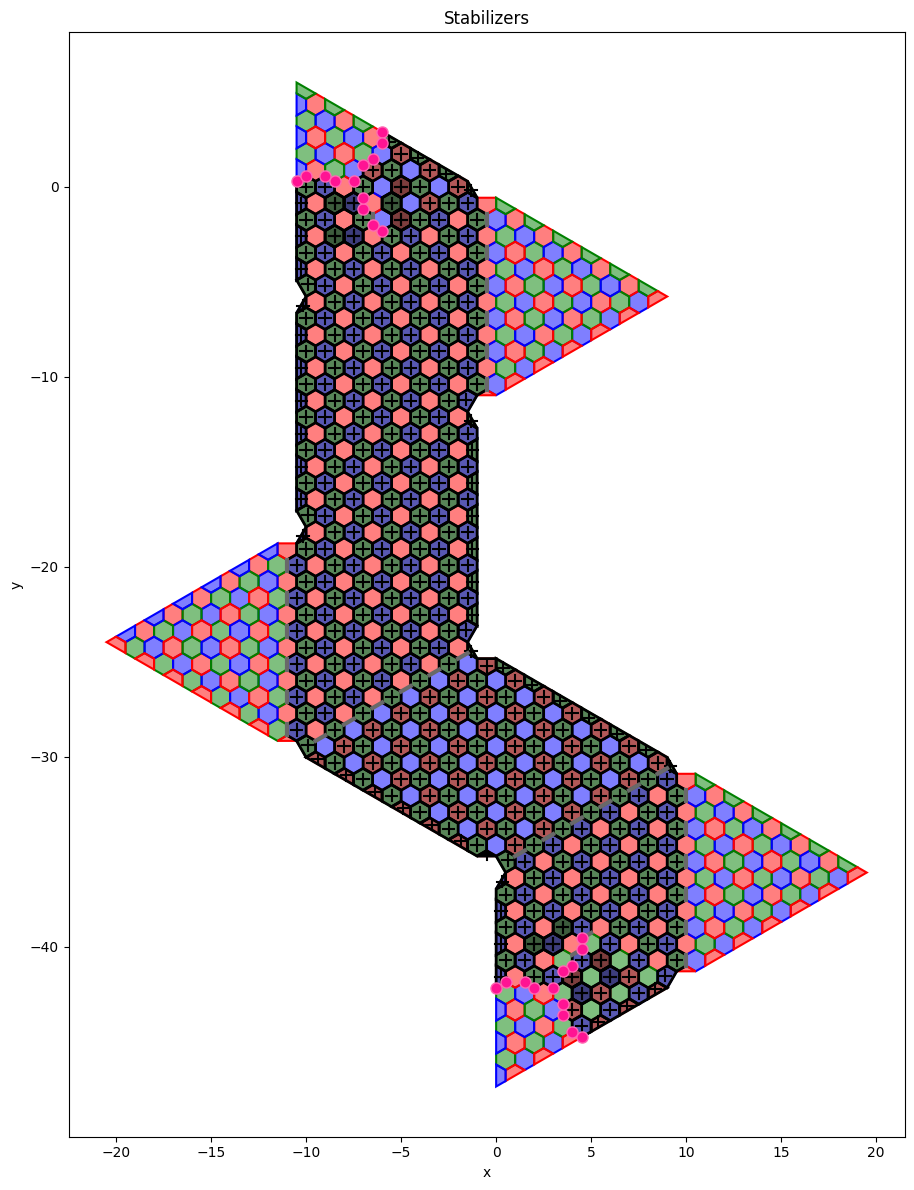

In [13]:
idx = 6
for el in all_paths[idx]:
    print(el)
plot_position_dict(size = (12,12), color_assignment=assignment, stabilizer_product = all_paths_stabilizer_product[idx], star_operators = stars[idx])